## Week10_복습과제_최지희
개요
- 목적: KV-cache 동작 원리 및 PagedAttention과의 관계를 간단히 설명
- 비교: cache 없음 vs cache 있음(연산 시간, 메모리)
- 제한: 단순 누적 캐시 구현 — 페이징/호스트 오프로드는 미포함

셋업: 필요 라이브러리 임포트

In [1]:
# 셀 1 - 라이브러리 import
import torch
import time
import matplotlib.pyplot as plt

하이퍼파라미터 설정: 모델/실험에 사용할 값들

In [2]:
# 셀 2 - 하이퍼파라미터 설정
hidden_size = 512
num_heads = 8
head_dim = hidden_size // num_heads
seq_lengths = [10, 50, 100, 200, 500]
vocab_size = 1000

Q/K/V 선형사상: 임베딩 → Q,K,V 생성 함수 정의

In [3]:
# 셀 3 - Linear projection 정의 (W_q, W_k, W_v)
torch.manual_seed(42)

W_q = torch.randn(hidden_size, hidden_size)
W_k = torch.randn(hidden_size, hidden_size)
W_v = torch.randn(hidden_size, hidden_size)
embedding = torch.randn(vocab_size, hidden_size)  # token embedding table

def get_qkv(token_ids):
    """
    token_ids: (seq_len,)
    → embedding lookup 후 W_q, W_k, W_v 곱해서 Q, K, V 생성
    """
    x = embedding[token_ids]        # (seq_len, hidden_size)
    Q = x @ W_q                     # (seq_len, hidden_size)
    K = x @ W_k                     # (seq_len, hidden_size)
    V = x @ W_v                     # (seq_len, hidden_size)
    return Q, K, V

Baseline: KV-cache 없이 매 스텝 전체 어텐션 계산

In [4]:
# 셀 4 - KV cache 없는 attention
def attention_without_cache(Q, K, V):
    scores = Q @ K.transpose(-2, -1) / (hidden_size ** 0.5)
    weights = torch.softmax(scores, dim=-1)
    return weights @ V

KV-cache 구현: 이전 K,V 누적하여 재사용(간단한 캐시)

In [5]:
# 셀 5 - KV cache 있는 attention
class AttentionWithKVCache:
    def __init__(self):
        self.k_cache = None
        self.v_cache = None

    def reset(self):
        self.k_cache = None
        self.v_cache = None

    def forward(self, token_id):
        """
        [논문 Section 2.2]
        token_id: int (현재 생성된 token 하나)
        → 현재 token의 Q, K, V만 계산하고 K, V는 cache에 누적
        → Q는 현재 token 것만 필요하므로 저장 안 함
        """
        x = embedding[token_id].unsqueeze(0)    # (1, hidden_size)
        q = x @ W_q                              # (1, hidden_size)
        k = x @ W_k                              # (1, hidden_size)
        v = x @ W_v                              # (1, hidden_size)

        # K, V만 cache에 누적
        if self.k_cache is None:
            self.k_cache = k
            self.v_cache = v
        else:
            self.k_cache = torch.cat([self.k_cache, k], dim=0)
            self.v_cache = torch.cat([self.v_cache, v], dim=0)

        # Q는 현재 token 것만, K와 V는 누적된 cache 사용
        scores = q @ self.k_cache.transpose(-2, -1) / (hidden_size ** 0.5) # K, V는 이전 모든 token의 것이 필요 → cache에서 불러옴
        weights = torch.softmax(scores, dim=-1)
        return weights @ self.v_cache

측정(벤치마크) 요약: 시퀀스별 연산 시간 비교(간단히)

In [6]:
# 셀 6 - 연산 시간 측정
times_without_cache = []
times_with_cache = []

for seq_len in seq_lengths:
    token_ids = torch.randint(0, vocab_size, (seq_len,))

    # cache 없는 방식
    start = time.time()
    for step in range(seq_len):
        Q, K, V = get_qkv(token_ids[:step+1])
        _ = attention_without_cache(Q, K, V)
    times_without_cache.append(time.time() - start)

    # cache 있는 방식
    attn = AttentionWithKVCache()
    attn.reset()
    start = time.time()
    for step in range(seq_len):
        _ = attn.forward(token_ids[step])
    times_with_cache.append(time.time() - start)

print("seq_len | w/o cache | with cache")
print("-" * 40)
for i, seq_len in enumerate(seq_lengths):
    print(f"{seq_len:7d} | {times_without_cache[i]:.4f}s   | {times_with_cache[i]:.4f}s")

seq_len | w/o cache | with cache
----------------------------------------
     10 | 0.0063s   | 0.0012s
     50 | 0.0128s   | 0.0051s
    100 | 0.0266s   | 0.0109s
    200 | 0.0709s   | 0.0278s
    500 | 0.5062s   | 0.0989s


cache 없는 방식 대비 속도 향상:
----------------------------------------
seq_len   10 → 5.16x 빠름
seq_len   50 → 2.51x 빠름
seq_len  100 → 2.45x 빠름
seq_len  200 → 2.55x 빠름
seq_len  500 → 5.12x 빠름


/tmp/ipykernel_3200680/2742047448.py:33: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3200680/2742047448.py:33: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/jiheechoi0102/jihi/jihi/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


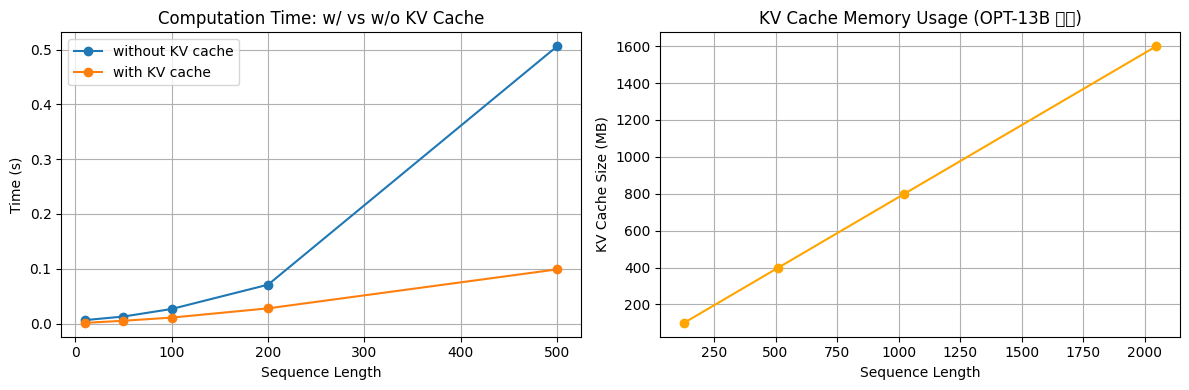

In [7]:
# 셀 7 - 속도 향상 배율 + 시각화
print("cache 없는 방식 대비 속도 향상:")
print("-" * 40)
for i, seq_len in enumerate(seq_lengths):
    speedup = times_without_cache[i] / times_with_cache[i]
    print(f"seq_len {seq_len:4d} → {speedup:.2f}x 빠름")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(seq_lengths, times_without_cache, marker='o', label='without KV cache')
axes[0].plot(seq_lengths, times_with_cache, marker='o', label='with KV cache')
axes[0].set_xlabel('Sequence Length')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Computation Time: w/ vs w/o KV Cache')
axes[0].legend()
axes[0].grid(True)

# KV cache 메모리 사용량 (OPT-13B 기준)
hidden_size_opt = 5120
num_layers_opt = 40
seq_lens_mem = [128, 512, 1024, 2048]
kv_cache_mb = [
    2 * hidden_size_opt * num_layers_opt * s * 2 / 1024**2
    for s in seq_lens_mem
]

axes[1].plot(seq_lens_mem, kv_cache_mb, marker='o', color='orange')
axes[1].set_xlabel('Sequence Length')
axes[1].set_ylabel('KV Cache Size (MB)')
axes[1].set_title('KV Cache Memory Usage (OPT-13B 기준)')
axes[1].grid(True)

plt.tight_layout()
plt.show()